# **MODELO DE CLASIFICACIÓN DE MATRICULADO/NO MATRICULADO**



Este notebook desarrolla un modelo de clasificación para predecir si un beneficiario de la beca finalmente se matricula o no. El objetivo es identificar patrones asociados al uso real de la beca con base en el df_model preparado en el EDA y sólo para beneficiarios de becas.

# Preparación del dataset

Se carga el df_model correspondiente, se seleccionan las variables relevantes y se aplican transformaciones básicas como codificación de variables categóricas antes del entrenamiento del modelo.

In [ ]:
import pandas as pd

file_path = "/content/df_model_final1 (2).xlsx"

# Cargar el dataset
df = pd.read_excel(file_path)

# Vista rápida
print("Dimensiones del dataset:", df.shape)
print("\nColumnas disponibles:")
print(df.columns.tolist())

# Conteo de valores nulos
print("\nValores nulos por columna:")
print(df.isna().sum())

# Balance de clases en la variable objetivo
print("\nDistribución de la variable 'Estado matricula':")
print(df["Estado de matricula"].value_counts(normalize=True) * 100)


Dimensiones del dataset: (2059, 18)

Columnas disponibles:
['ID_anon', 'Resultado Final', 'puntos_academicos_int', 'Pregrado al que aspiras', 'Estado de matricula', '% beca talento final aprobada', 'Entrevista', 'paso_entrevista', 'Ensayo', 'paso_ensayo', 'dependencia_economica', 'Padres_profesionales', 'log_ingresos_padres', 'puntos_estrato', 'analisis_economico', 'Edad al postularse', 'Sexo biológico', 'Dpto de Residencia']

Valores nulos por columna:
ID_anon                          0
Resultado Final                  0
puntos_academicos_int            0
Pregrado al que aspiras          0
Estado de matricula              0
% beca talento final aprobada    0
Entrevista                       0
paso_entrevista                  0
Ensayo                           0
paso_ensayo                      0
dependencia_economica            0
Padres_profesionales             0
log_ingresos_padres              0
puntos_estrato                   0
analisis_economico               0
Edad al postulars

# División del conjunto de datos

Los datos se dividen en entrenamiento y prueba utilizando partición estratificada, con el fin de mantener la proporción original entre quienes usan y no usan la beca.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Eliminar columnas no predictoras o que no se deben usar como features
df_model = df.drop(
    columns=["ID_anon"]
)

# Variable objetivo: uso efectivo de la beca
# 1 = Usa la beca (se matricula), 0 = No usa la beca (no se matricula)
y = df_model["Estado de matricula"].map({"Uso beca": 1, "No uso beca": 0})
X = df_model.drop(columns=["Estado de matricula"])

In [ ]:
# Identificar tipos de variables
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Variables categóricas:", cat_cols)
print("Variables numéricas:", num_cols)

Variables categóricas: ['Resultado Final', 'Pregrado al que aspiras', 'Sexo biológico', 'Dpto de Residencia']
Variables numéricas: ['puntos_academicos_int', '% beca talento final aprobada', 'Entrevista', 'paso_entrevista', 'Ensayo', 'paso_ensayo', 'dependencia_economica', 'Padres_profesionales', 'log_ingresos_padres', 'puntos_estrato', 'analisis_economico', 'Edad al postularse']


In [ ]:
# OneHotEncoding (para categóricas)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("\nDimensiones después de OneHotEncoding:", X_encoded.shape)


Dimensiones después de OneHotEncoding: (2059, 81)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

print("\nTamaños de los conjuntos:")
print("Entrenamiento:", X_train.shape, "Prueba:", X_test.shape)
print("\nDistribución de clases (train):")
print(y_train.value_counts(normalize=True))



Tamaños de los conjuntos:
Entrenamiento: (1441, 81) Prueba: (618, 81)

Distribución de clases (train):
Estado de matricula
0    0.537821
1    0.462179
Name: proportion, dtype: float64


# Árbol de decisión (modelo base)

Se entrena un Árbol de Decisión como referencia inicial. Se muestran métricas básicas, matriz de confusión e importancia de las variables para conocer su funcionamiento preliminar.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Definir y entrenar el modelo
dt = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=None,
    random_state=42
)

dt.fit(X_train, y_train)

# Predicciones
y_pred = dt.predict(X_test)

# Métricas principales
print("Árbol de Decisión (base)")
print(classification_report(
    y_test, y_pred,
    target_names=["No usa beca", "Usa beca"]
))

f1 = f1_score(y_test, y_pred)
print(f"F1-Score global: {f1:.3f}")

Árbol de Decisión (base)
              precision    recall  f1-score   support

 No usa beca       0.63      0.64      0.64       333
    Usa beca       0.57      0.55      0.56       285

    accuracy                           0.60       618
   macro avg       0.60      0.60      0.60       618
weighted avg       0.60      0.60      0.60       618

F1-Score global: 0.562


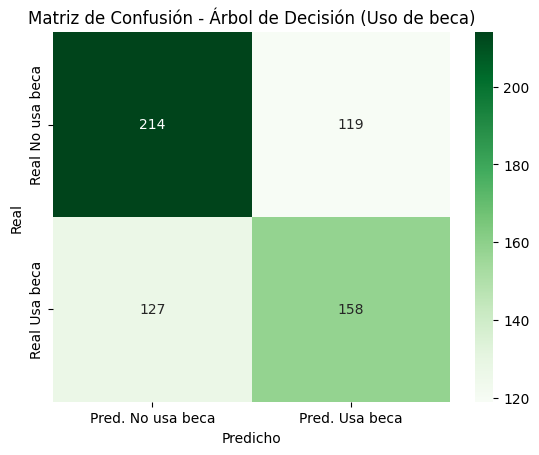

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Pred. No usa beca", "Pred. Usa beca"],
    yticklabels=["Real No usa beca", "Real Usa beca"]
)
plt.title("Matriz de Confusión - Árbol de Decisión (Uso de beca)")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()



/tmp/ipython-input-3198672543.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vars.values, y=top_vars.index, palette="viridis")


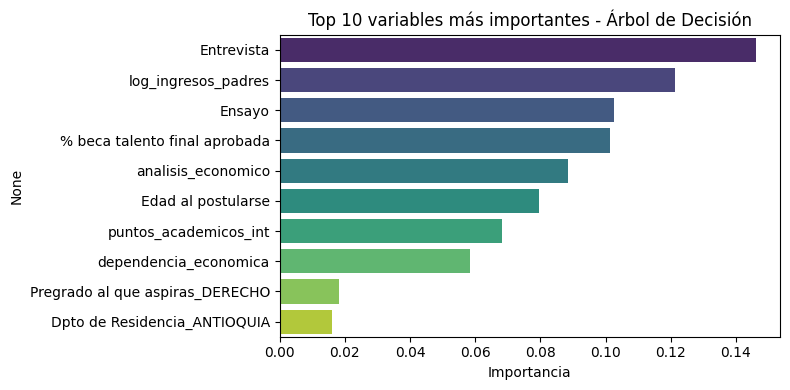

In [ ]:
importances = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_vars = importances.head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=top_vars.values, y=top_vars.index, palette="viridis")
plt.title("Top 10 variables más importantes - Árbol de Decisión")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

# Random Forest (modelo base)

Se ajusta un Random Forest para lograr mayor estabilidad en las predicciones. Se presentan métricas, matriz de confusión y la lista de variables más influyentes en el modelo.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

# Predicción y probas
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

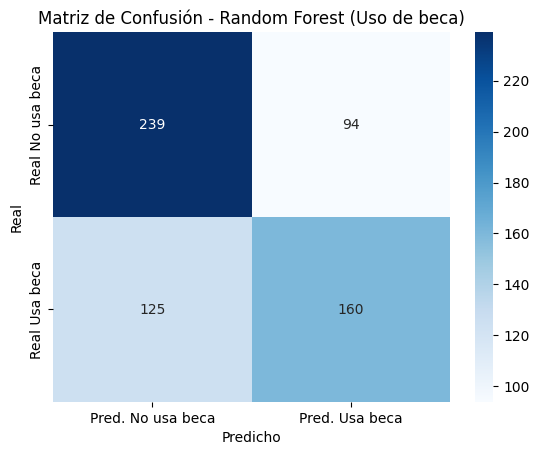

Random Forest (base)
              precision    recall  f1-score   support

 No usa beca       0.66      0.72      0.69       333
    Usa beca       0.63      0.56      0.59       285

    accuracy                           0.65       618
   macro avg       0.64      0.64      0.64       618
weighted avg       0.64      0.65      0.64       618

F1-Score global: 0.594


In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred. No usa beca", "Pred. Usa beca"],
    yticklabels=["Real No usa beca", "Real Usa beca"]
)
plt.title("Matriz de Confusión - Random Forest (Uso de beca)")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()

print("Random Forest (base)")
print(classification_report(
    y_test, y_pred_rf,
    target_names=["No usa beca", "Usa beca"]
))
print(f"F1-Score global: {f1_score(y_test, y_pred_rf):.3f}")


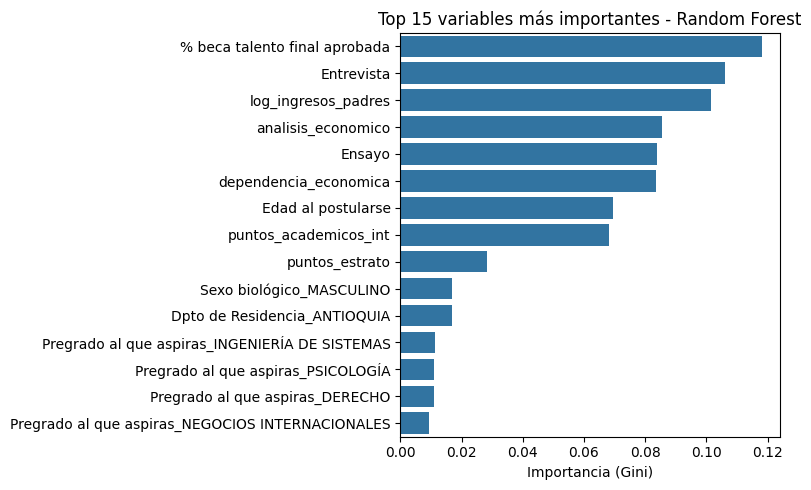

In [ ]:
importances_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_vars_rf = importances_rf.head(15)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_vars_rf.values, y=top_vars_rf.index)
plt.title("Top 15 variables más importantes - Random Forest")
plt.xlabel("Importancia (Gini)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# XGBoost (modelo base)

Se entrena un modelo XGBoost configurado para manejar el desbalance entre clases. Este modelo permite capturar relaciones no lineales relevantes para el comportamiento de matrícula.


Relación No usa / Usa beca (train) = 1.16


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:30:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost (base) ===
              precision    recall  f1-score   support

 No usa beca       0.66      0.65      0.66       333
    Usa beca       0.60      0.61      0.60       285

    accuracy                           0.63       618
   macro avg       0.63      0.63      0.63       618
weighted avg       0.63      0.63      0.63       618

F1-Score global: 0.603


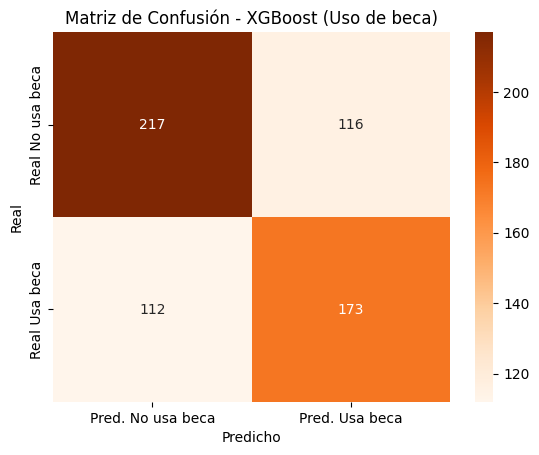

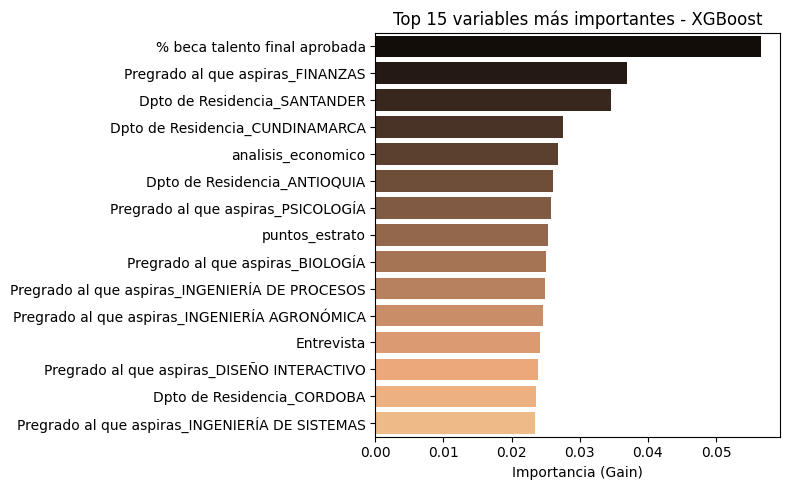

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calcular balance de clases
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"\nRelación No usa / Usa beca (train) = {ratio:.2f}")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("\n=== XGBoost (base) ===")
print(classification_report(
    y_test, y_pred_xgb,
    target_names=["No usa beca", "Usa beca"]
))
print(f"F1-Score global: {f1_score(y_test, y_pred_xgb):.3f}")

cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Oranges",
    xticklabels=["Pred. No usa beca", "Pred. Usa beca"],
    yticklabels=["Real No usa beca", "Real Usa beca"]
)
plt.title("Matriz de Confusión - XGBoost (Uso de beca)")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()

importances_xgb = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_vars_xgb = importances_xgb.head(15)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_vars_xgb.values, y=top_vars_xgb.index, hue=top_vars_xgb.index, palette="copper", legend=False)
plt.title("Top 15 variables más importantes - XGBoost")
plt.xlabel("Importancia (Gain)")
plt.ylabel("")
plt.tight_layout()
plt.show()


# Comparación de modelos

Se comparan los desempeños de Árbol, Random Forest y XGBoost utilizando métricas como Precisión, Recall y F1-score para determinar cuál se ajusta mejor a este problema.

,Modelo,Precisión,Recall,F1-Score
2,XGBoost,0.598616,0.607018,0.602787
1,Random Forest,0.629921,0.561404,0.593692
0,Árbol de Decisión,0.570397,0.554386,0.562278


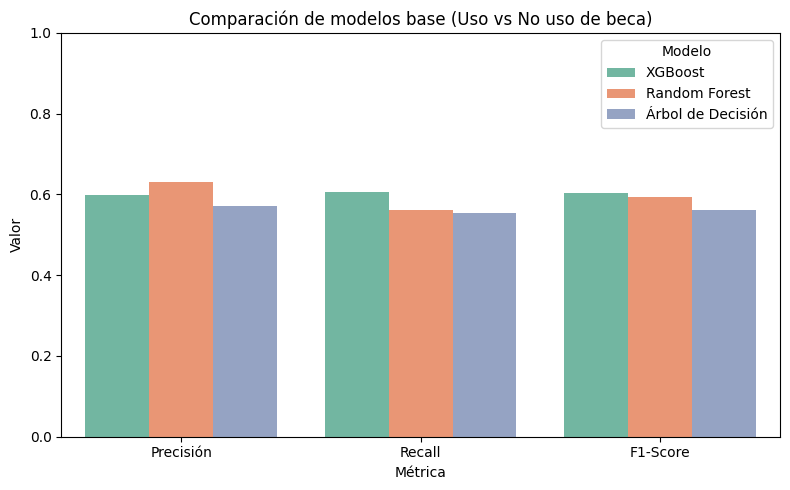

Mejor modelo base: XGBoost (F1=0.603)


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Árbol de Decisión": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = []
for name, model in models.items():
    y_pred_model = model.predict(X_test)
    results.append({
        "Modelo": name,
        "Precisión": precision_score(y_test, y_pred_model, zero_division=0),
        "Recall": recall_score(y_test, y_pred_model, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred_model, zero_division=0)
    })

df_results = pd.DataFrame(results).sort_values("F1-Score", ascending=False)
display(df_results)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_results.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor"),
    x="Métrica", y="Valor", hue="Modelo", palette="Set2"
)
plt.title("Comparación de modelos base (Uso vs No uso de beca)")
plt.ylim(0, 1)
plt.legend(title="Modelo")
plt.tight_layout()
plt.show()

best_model_base = df_results.iloc[0]
print(f"Mejor modelo base: {best_model_base['Modelo']} (F1={best_model_base['F1-Score']:.3f})")


In [ ]:
# Mejor modelo según F1
best_model = df_results.iloc[0]
print(f"Mejor modelo: {best_model['Modelo']} (F1={best_model['F1-Score']:.3f})")


Mejor modelo: XGBoost (F1=0.603)


# **Aplicación de técnicas de optimización de los modelos**

# SMOTE y análisis de su impacto

Se prueba SMOTE para equilibrar la clase minoritaria. Aunque mejora momentáneamente la representatividad, puede introducir ruido y no se adopta como enfoque final. Se compara el desempeño con y sin SMOTE para evaluar su efecto real.

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Distribución original:")
print(y_train.value_counts())

print("\nDistribución balanceada con SMOTE:")
print(y_train_sm.value_counts())


Distribución original:
Estado de matricula
0    775
1    666
Name: count, dtype: int64

Distribución balanceada con SMOTE:
Estado de matricula
1    775
0    775
Name: count, dtype: int64


In [ ]:
dt_smote = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=None,
    random_state=42
)

dt_smote.fit(X_train_sm, y_train_sm)

# Predicciones sobre el test (sin SMOTE)
y_pred_smote = dt_smote.predict(X_test)

print("Árbol de Decisión con SMOTE")
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote, target_names=["No uso beca", "Uso beca"]))

f1 = f1_score(y_test, y_pred_smote)
print(f"\nF1-Score con SMOTE: {f1:.3f}")





Árbol de Decisión con SMOTE
[[196 137]
 [129 156]]
              precision    recall  f1-score   support

 No uso beca       0.60      0.59      0.60       333
    Uso beca       0.53      0.55      0.54       285

    accuracy                           0.57       618
   macro avg       0.57      0.57      0.57       618
weighted avg       0.57      0.57      0.57       618


F1-Score con SMOTE: 0.540


# Comparación de Modelos con y sin SMOTE


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pl

In [ ]:
y_pred_base  = dt.predict(X_test)        # Árbol original
y_pred_smote = dt_smote.predict(X_test)  # Árbol entrenado con SMOTE

In [ ]:
print("ÁRBOL DE DECISIÓN - SIN SMOTE")
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_base))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_base, target_names=["No uso beca", "uso beca"]))

f1_base = f1_score(y_test, y_pred_base)
print(f"F1-Score SIN SMOTE: {f1_base:.3f}")

ÁRBOL DE DECISIÓN - SIN SMOTE
Matriz de confusión:
[[214 119]
 [127 158]]

Reporte de clasificación:
              precision    recall  f1-score   support

 No uso beca       0.63      0.64      0.64       333
    uso beca       0.57      0.55      0.56       285

    accuracy                           0.60       618
   macro avg       0.60      0.60      0.60       618
weighted avg       0.60      0.60      0.60       618

F1-Score SIN SMOTE: 0.562


In [ ]:
print("ÁRBOL DE DECISIÓN - CON SMOTE ")
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_smote))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_smote, target_names=["No uso beca", "Uso beca"]))

f1_smote = f1_score(y_test, y_pred_smote)
print(f"F1-Score CON SMOTE: {f1_smote:.3f}")

ÁRBOL DE DECISIÓN - CON SMOTE 
Matriz de confusión:
[[196 137]
 [129 156]]

Reporte de clasificación:
              precision    recall  f1-score   support

 No uso beca       0.60      0.59      0.60       333
    Uso beca       0.53      0.55      0.54       285

    accuracy                           0.57       618
   macro avg       0.57      0.57      0.57       618
weighted avg       0.57      0.57      0.57       618

F1-Score CON SMOTE: 0.540


COMPARATIVO
            Modelo  F1-Score
0  Árbol sin SMOTE  0.562278
1  Árbol con SMOTE  0.539792


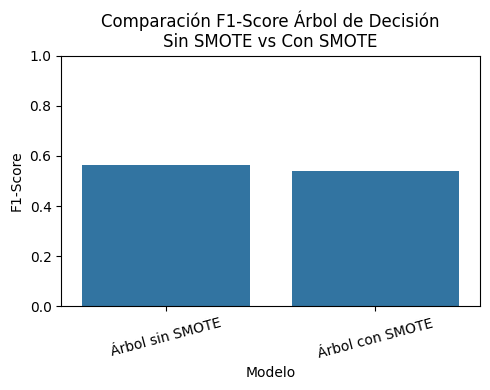

In [ ]:
comparacion = pd.DataFrame({
    "Modelo": ["Árbol sin SMOTE", "Árbol con SMOTE"],
    "F1-Score": [f1_base, f1_smote]
})

print("COMPARATIVO")
print(comparacion)

#Comparación visual
plt.figure(figsize=(5,4))
sns.barplot(data=comparacion, x="Modelo", y="F1-Score")
plt.title("Comparación F1-Score Árbol de Decisión\nSin SMOTE vs Con SMOTE")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

La optimización con SMOTE no fue eficiente considerando que el F1 Score disminuyó. Esto se debe a que la asignación de becas por naturaleza es un problema con desbalance de clases. Considerando lo anterior, se selecciona el modelo antes del smote para compararlo con Random Forest y XGBoots

# Optimización con GridSearch

Se realiza búsqueda de hiperparámetros para mejorar el rendimiento del Árbol de Decisión y el Random Forest, probando distintas profundidades y configuraciones que puedan aumentar la capacidad del mode

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# Árboles de decisión

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

dt_base = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)


In [ ]:
param_grid_dt = {
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy"]
}



In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

print("Mejores parámetros (Árbol de Decisión):")
print(grid_dt.best_params_)
print(f"F1 promedio CV: {grid_dt.best_score_:.4f}")


Fitting 5 folds for each of 160 candidates, totalling 800 fits
Mejores parámetros (Árbol de Decisión):
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 2}
F1 promedio CV: 0.6188


In [ ]:
best_dt = grid_dt.best_estimator_

y_pred_dt_best = best_dt.predict(X_test)
f1_dt_best = f1_score(y_test, y_pred_dt_best)

print("\nÁrbol optimizado (GridSearch)")
print(classification_report(y_test, y_pred_dt_best, target_names=["No uso beca", "Uso beca"]))
print(f"F1-Score test optimizado: {f1_dt_best:.3f}")



Árbol optimizado (GridSearch)
              precision    recall  f1-score   support

 No uso beca       0.63      0.60      0.61       333
    Uso beca       0.55      0.59      0.57       285

    accuracy                           0.59       618
   macro avg       0.59      0.59      0.59       618
weighted avg       0.59      0.59      0.59       618

F1-Score test optimizado: 0.570


In [ ]:
df_comp_dt = pd.DataFrame({
    "Modelo": ["Árbol base", "Árbol GridSearch"],
    "F1_test": [f1, f1_dt_best]
})

df_comp_dt


,Modelo,F1_test
0,Árbol base,0.539792
1,Árbol GridSearch,0.569966


#Random Forest

In [ ]:
y_pred_rf_base = rf.predict(X_test)
f1_rf_base = f1_score(y_test, y_pred_rf_base)

print("\nRandom Forest BASE")
print(classification_report(
    y_test, y_pred_rf_base,
    target_names=["No usa beca", "Usa beca"]
))
print(f"F1-Score test (base): {f1_rf_base:.3f}")

rf_base = RandomForestClassifier(
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

param_grid_rf = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring="f1",
    n_jobs=-1,
    cv=cv,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("\nMejores parámetros encontrados (RF):")
print(grid_rf.best_params_)
print(f"F1 promedio en CV: {grid_rf.best_score_:.4f}")


Random Forest BASE
              precision    recall  f1-score   support

 No usa beca       0.66      0.72      0.69       333
    Usa beca       0.63      0.56      0.59       285

    accuracy                           0.65       618
   macro avg       0.64      0.64      0.64       618
weighted avg       0.64      0.65      0.64       618

F1-Score test (base): 0.594
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Mejores parámetros encontrados (RF):
{'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 600}
F1 promedio en CV: 0.6132


In [ ]:
best_rf = grid_rf.best_estimator_
y_pred_rf_best = best_rf.predict(X_test)
f1_rf_best = f1_score(y_test, y_pred_rf_best)

print("\nRandom Forest Optimizado (GridSearch)")
print(classification_report(
    y_test, y_pred_rf_best,
    target_names=["No usa beca", "Usa beca"]
))
print(f"F1-Score test (optimizado): {f1_rf_best:.3f}")

df_comp_rf = pd.DataFrame({
    "Modelo": ["RF base", "RF GridSearch"],
    "F1_test": [f1_rf_base, f1_rf_best]
})
display(df_comp_rf)


Random Forest Optimizado (GridSearch)
              precision    recall  f1-score   support

 No usa beca       0.67      0.71      0.69       333
    Usa beca       0.64      0.59      0.61       285

    accuracy                           0.66       618
   macro avg       0.65      0.65      0.65       618
weighted avg       0.66      0.66      0.66       618

F1-Score test (optimizado): 0.615


,Modelo,F1_test
0,RF base,0.593692
1,RF GridSearch,0.614545


In [ ]:
import pandas as pd

df_comp_rf = pd.DataFrame({
    "Modelo": ["RF base", "RF GridSearch"],
    "F1_test": [f1_rf_base, f1_rf_best]
})
display(df_comp_rf)



,Modelo,F1_test
0,RF base,0.593692
1,RF GridSearch,0.614545


# XGBoots

In [ ]:
xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False
)

xgb_base.fit(X_train, y_train)
y_pred_xgb_base = xgb_base.predict(X_test)
f1_xgb_base = f1_score(y_test, y_pred_xgb_base)
print(f"\nF1-Score XGBoost base: {f1_xgb_base:.3f}")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:50:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



F1-Score XGBoost base: 0.603


In [ ]:
param_grid_xgb = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=ratio,
        eval_metric="logloss",
        random_state=42,
        use_label_encoder=False
    ),
    param_grid=param_grid_xgb,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print("\nMejores parámetros encontrados (XGBoost):")
print(grid_xgb.best_params_)
print(f"F1 promedio CV: {grid_xgb.best_score_:.4f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits

Mejores parámetros encontrados (XGBoost):
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
F1 promedio CV: 0.6384


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:54:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
best_xgb = grid_xgb.best_estimator_
y_pred_xgb_best = best_xgb.predict(X_test)
f1_xgb_best = f1_score(y_test, y_pred_xgb_best)

print("\nXGBoost optimizado (GridSearch)")
print(classification_report(
    y_test, y_pred_xgb_best,
    target_names=["No usa beca", "Usa beca"]
))
print(f"F1-Score test optimizado: {f1_xgb_best:.3f}")

df_comp_xgb = pd.DataFrame({
    "Modelo": ["XGBoost base", "XGBoost GridSearch"],
    "F1_test": [f1_xgb_base, f1_xgb_best]
})
display(df_comp_xgb)


XGBoost optimizado (GridSearch)
              precision    recall  f1-score   support

 No usa beca       0.67      0.66      0.66       333
    Usa beca       0.61      0.61      0.61       285

    accuracy                           0.64       618
   macro avg       0.64      0.64      0.64       618
weighted avg       0.64      0.64      0.64       618

F1-Score test optimizado: 0.609


,Modelo,F1_test
0,XGBoost base,0.602787
1,XGBoost GridSearch,0.609457


# Comparación de modelos con GridSearch

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
modelos = {
    "DT base": dt,                      # Árbol que entrenaste sin grid
    "DT tunado": grid_dt.best_estimator_,
    "RF base": rf,                      # Random Forest original
    "RF tunado": grid_rf.best_estimator_,
    "XGB base": xgb,                    # XGBoost original
    "XGB tunado": grid_xgb.best_estimator_
}

In [ ]:
filas = []
for nombre, modelo in modelos.items():
    # predicciones duras (0/1)
    y_pred = modelo.predict(X_test)

    # probabilidades para calcular AUC (si el modelo las tiene)
    try:
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    except Exception:
        auc = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    filas.append({
        "Modelo": nombre,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1-Score": round(f1, 3),
        "ROC-AUC": round(auc, 3) if auc is not None else None
    })

resumen_modelos = pd.DataFrame(filas).sort_values("F1-Score", ascending=False).reset_index(drop=True)

resumen_modelos

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,RF tunado,0.657,0.638,0.593,0.615,0.717
1,XGB tunado,0.639,0.608,0.611,0.609,0.712
2,XGB base,0.631,0.599,0.607,0.603,0.681
3,RF base,0.646,0.630,0.561,0.594,0.715
4,DT tunado,0.592,0.555,0.586,0.570,0.624
5,DT base,0.602,0.570,0.554,0.562,0.599


# Curvas de ROC

Se calculan y grafican las curvas ROC para los diferentes modelos con el objetivo de evaluar su capacidad de discriminación entre estudiantes que utilizan la beca y quienes no la utilizan. La curva ROC permite observar el equilibrio entre la tasa de verdaderos positivos y la tasa de falsos positivos a distintos umbrales de decisión. Esta visualización complementa las métricas tradicionales y facilita comparar de manera rápida cuál modelo presenta una mejor separación entre clases según el área bajo la curva (AUC).

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
y_proba_dt  = best_dt.predict_proba(X_test)[:, 1]
y_proba_rf  = best_rf.predict_proba(X_test)[:, 1]
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]



In [ ]:
fpr_dt,  tpr_dt,  _ = roc_curve(y_test, y_proba_dt)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

In [ ]:
auc_dt  = auc(fpr_dt, tpr_dt)
auc_rf  = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

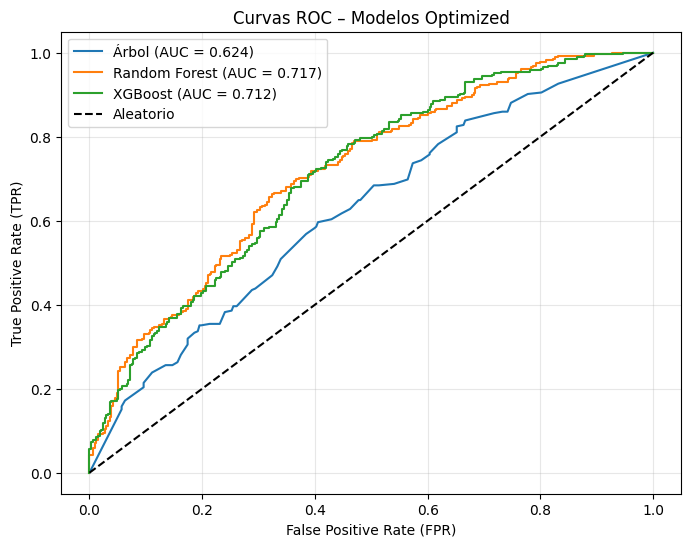

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(fpr_dt,  tpr_dt,  label=f"Árbol (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf,  tpr_rf,  label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

plt.plot([0,1], [0,1], "k--", label="Aleatorio")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curvas ROC – Modelos Optimized")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La comparación mediante la curva ROC se realizó con los modelos optimizados mediante GridSearch, garantizando una evaluación homogénea y consistente entre los modelos

# Optimizacion de XGBooots con Optuna

In [ ]:
!pip install optuna

import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 7.3 MB/s eta 0:00:00


In [ ]:

def objetivo(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, ratio),
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    f1 = cross_val_score(model, X_train, y_train, scoring="f1", cv=cv, n_jobs=-1).mean()

    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objetivo, n_trials=40, show_progress_bar=True)




[I 2025-11-28 01:54:19,641] A new study created in memory with name: no-name-3451d04d-6103-4203-8b81-85acd4133b4d


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-11-28 01:54:29,066] Trial 0 finished with value: 0.6077456355688503 and parameters: {'n_estimators': 951, 'max_depth': 7, 'learning_rate': 0.1114431670764632, 'subsample': 0.634088944968211, 'colsample_bytree': 0.7744950066375907, 'gamma': 0.44659216236520194, 'min_child_weight': 10, 'scale_pos_weight': 1.1612732461449615}. Best is trial 0 with value: 0.6077456355688503.
[I 2025-11-28 01:54:35,194] Trial 1 finished with value: 0.6237025761344287 and parameters: {'n_estimators': 887, 'max_depth': 10, 'learning_rate': 0.20401690030723887, 'subsample': 0.661406738028918, 'colsample_bytree': 0.9248961204696251, 'gamma': 3.8929113996154285, 'min_child_weight': 8, 'scale_pos_weight': 1.1570594659795115}. Best is trial 1 with value: 0.6237025761344287.
[I 2025-11-28 01:54:38,795] Trial 2 finished with value: 0.6102055724501916 and parameters: {'n_estimators': 590, 'max_depth': 4, 'learning_rate': 0.19588586923891577, 'subsample': 0.8482906067552938, 'colsample_bytree': 0.8954111651755

In [ ]:
print("Mejores parámetros:")
print(study.best_params)

print("\nMejor F1 obtenido:")
print(study.best_value)

Mejores parámetros:
{'n_estimators': 402, 'max_depth': 6, 'learning_rate': 0.07549642267268415, 'subsample': 0.7928126421676817, 'colsample_bytree': 0.7300274740407408, 'gamma': 3.247096924332576, 'min_child_weight': 5, 'scale_pos_weight': 1.1465962800495126}

Mejor F1 obtenido:
0.625531570403095


In [ ]:
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


best_params = study.best_params.copy()
best_params.update({
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1,
    "use_label_encoder": False
})

xgb_opt = XGBClassifier(**best_params)
xgb_opt.fit(X_train, y_train)

y_pred_opt = xgb_opt.predict(X_test)
f1_opt = f1_score(y_test, y_pred_opt)
print(f"F1-Score XGBoost (Optuna): {f1_opt:.3f}")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:56:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


F1-Score XGBoost (Optuna): 0.593


# Evaluación final de todos los modelos

Se consolidan las métricas principales (Precisión, Recall, F1 y AUC) de todos los modelos entrenados para evaluar su desempeño de forma unificada. Esta comparación permite identificar cuál algoritmo logra un mejor equilibrio entre sensibilidad y precisión para la predicción de uso real de la beca.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

def evaluar_modelo(nombre, modelo, X_test, y_test):

    y_pred = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc = np.nan

    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc
    }


In [ ]:
resultados = []

resultados.append(evaluar_modelo("DT base", dt, X_test, y_test))
resultados.append(evaluar_modelo("DT + SMOTE", dt_smote, X_test, y_test))

resultados.append(evaluar_modelo("DT (GridSearch)", best_dt, X_test, y_test))

resultados.append(evaluar_modelo("RF base", rf, X_test, y_test))
resultados.append(evaluar_modelo("RF (GridSearch)", best_rf, X_test, y_test))

resultados.append(evaluar_modelo("XGB base", xgb, X_test, y_test))
resultados.append(evaluar_modelo("XGB (GridSearch)",grid_xgb.best_estimator_, X_test, y_test))

resultados.append(evaluar_modelo("XGB (Optuna)", xgb_opt, X_test, y_test))

df_modelos = pd.DataFrame(resultados)
df_modelos = df_modelos.sort_values(by="F1", ascending=False).reset_index(drop=True)

print("Comparación final de modelos (ordenados por F1):")
display(df_modelos)



Comparación final de modelos (ordenados por F1):


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,RF (GridSearch),0.656958,0.637736,0.592982,0.614545,0.716917
1,XGB (GridSearch),0.639159,0.608392,0.610526,0.609457,0.712207
2,XGB base,0.631068,0.598616,0.607018,0.602787,0.681218
3,RF base,0.645631,0.629921,0.561404,0.593692,0.715052
4,XGB (Optuna),0.631068,0.603636,0.582456,0.592857,0.690923
5,DT (GridSearch),0.592233,0.554817,0.585965,0.569966,0.623776
6,DT base,0.601942,0.570397,0.554386,0.562278,0.598514
7,DT + SMOTE,0.569579,0.532423,0.547368,0.539792,0.567979


Dado que los modelos base y optimizados no alcanzaron un F1-score suficientemente alto para este problema, se entrenaron modelos adicionales con configuraciones alternativas y técnicas complementarias. Este paso busca explorar arquitecturas más robustas y mejorar la capacidad predictiva frente al desbalance y la variabilidad de la clase minoritaria. Aunque los incrementos son moderados, estas pruebas permiten identificar configuraciones más estables y comprender mejor las limitaciones del conjunto de datos

# Catboots

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.0 MB/s eta 0:00:00

=== CatBoost (base) ===
              precision    recall  f1-score   support

 No usa beca       0.66      0.67      0.66       333
    Usa beca       0.61      0.59      0.60       285

    accuracy                           0.63       618
   macro avg       0.63      0.63      0.63       618
weighted avg       0.63      0.63      0.63       618

F1-Score: 0.599


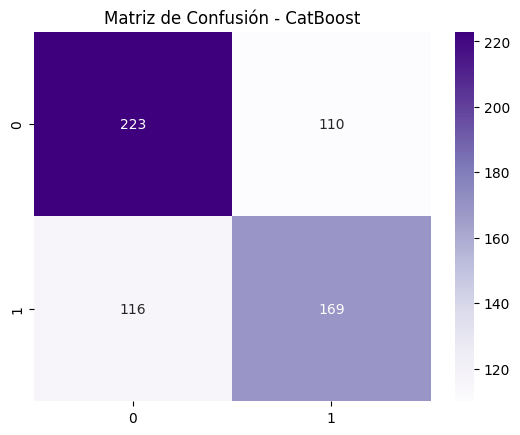

In [ ]:
!pip install catboost

from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="F1",
    verbose=0,
    random_state=42,
    class_weights=[1, ratio]
)

cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)
f1_cat = f1_score(y_test, y_pred_cat)

print("\n=== CatBoost (base) ===")
print(classification_report(
    y_test, y_pred_cat,
    target_names=["No usa beca", "Usa beca"]
))
print(f"F1-Score: {f1_cat:.3f}")

cm = confusion_matrix(y_test, y_pred_cat)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Matriz de Confusión - CatBoost")
plt.show()


# LightGBM (LGBMClassifier)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 666, number of negative: 775
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000842 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1080
[LightGBM] [Info] Number of data points in the train set: 1441, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000

=== LightGBM (base) ===
              precision    recall  f1-score   support

 No usa beca       0.62      0.65      0.63       333
    Usa beca       0.56      0.54      0.55       285

    accuracy                           0.60       618
   macro avg       0.59      0.59      0.59       618
weighted avg       0.59      0.60      0.59       618

F1-Score: 0.550

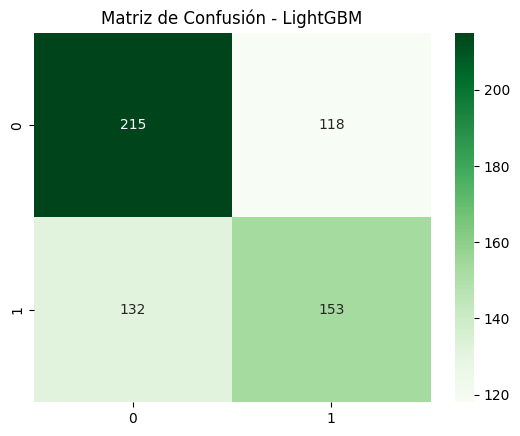

In [ ]:
!pip install lightgbm

from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    class_weight="balanced",
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict(X_test)
f1_lgb = f1_score(y_test, y_pred_lgb)

print("\n=== LightGBM (base) ===")
print(classification_report(
    y_test, y_pred_lgb,
    target_names=["No usa beca", "Usa beca"]
))
print(f"F1-Score: {f1_lgb:.3f}")

cm = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de Confusión - LightGBM")
plt.show()


# LogisticRegression


=== Logistic Regression (base) ===
              precision    recall  f1-score   support

 No usa beca       0.67      0.56      0.61       333
    Usa beca       0.56      0.67      0.61       285

    accuracy                           0.61       618
   macro avg       0.62      0.61      0.61       618
weighted avg       0.62      0.61      0.61       618

F1-Score: 0.614


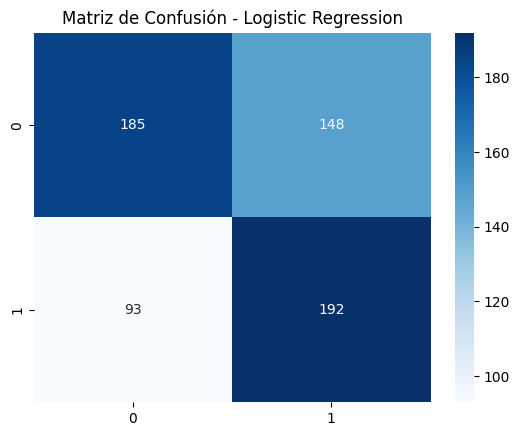

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    class_weight="balanced",
    max_iter=500,
    random_state=42
)

logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
f1_logreg = f1_score(y_test, y_pred_logreg)

print("\n=== Logistic Regression (base) ===")
print(classification_report(
    y_test, y_pred_logreg,
    target_names=["No usa beca", "Usa beca"]
))
print(f"F1-Score: {f1_logreg:.3f}")

cm = confusion_matrix(y_test, y_pred_logreg)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Logistic Regression")
plt.show()


In [ ]:
df_new_models = pd.DataFrame({
    "Modelo": ["CatBoost", "LightGBM", "Logistic Regression"],
    "F1_Score": [f1_cat, f1_lgb, f1_logreg]
})

display(df_new_models)


,Modelo,F1_Score
0,CatBoost,0.599291
1,LightGBM,0.550360
2,Logistic Regression,0.614400


# Optimización con GridSearch

A los modelos adicionales, también se les realiza una optimización hiperparámetros

#1. LogisticRegression

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    "penalty": ["l1", "l2", "elasticnet"],
    "C": [0.001, 0.01, 0.1, 1, 10],
    "solver": ["liblinear", "saga"],
    "l1_ratio": [0, 0.25, 0.5, 0.75, 1]  # para elasticnet
}

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

grid_lr = GridSearchCV(
    lr,
    param_grid_lr,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)

f1_lr_best = f1_score(y_test, y_pred_lr)

print("\n=== Logistic Regression (Tuned) ===")
print("Mejores parámetros:", grid_lr.best_params_)
print(classification_report(y_test, y_pred_lr))
print("F1:", f1_lr_best)


Fitting 5 folds for each of 150 candidates, totalling 750 fits

=== Logistic Regression (Tuned) ===
Mejores parámetros: {'C': 10, 'l1_ratio': 0, 'penalty': 'l1', 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.71      0.69      0.70       333
           1       0.65      0.67      0.66       285

    accuracy                           0.68       618
   macro avg       0.68      0.68      0.68       618
weighted avg       0.68      0.68      0.68       618

F1: 0.6586206896551724


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
125 fits failed out of a total of 750.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
125 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_sol

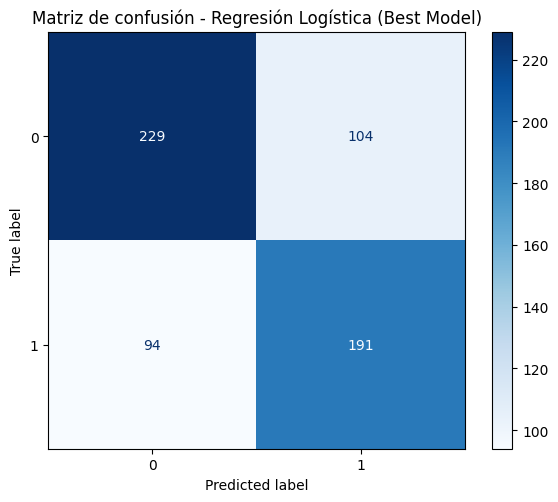

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predicciones con el mejor modelo
y_pred_lr = best_lr.predict(X_test)

# Matriz de confusión (conteos)
cm = confusion_matrix(y_test, y_pred_lr)

# Visualización
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', colorbar=True, ax=ax)

ax.set_title("Matriz de confusión - Regresión Logística (Best Model)", fontsize=12)
plt.tight_layout()



# 2. CatboostClassifier

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="F1",
    class_weights=[1, ratio],
    random_state=42,
    verbose=0
)

param_dist_cat = {
    "iterations": [300, 500, 700, 900],
    "depth": [4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9]
}

rand_cat = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist_cat,
    n_iter=20,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

rand_cat.fit(X_train, y_train)

best_cat = rand_cat.best_estimator_
y_pred_cat_best = best_cat.predict(X_test)

f1_cat_best = f1_score(y_test, y_pred_cat_best)

print("\n=== CatBoost (Tuned) ===")
print("Mejores parámetros:", rand_cat.best_params_)
print(classification_report(y_test, y_pred_cat_best))
print("F1:", f1_cat_best)


Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== CatBoost (Tuned) ===
Mejores parámetros: {'learning_rate': 0.01, 'l2_leaf_reg': 3, 'iterations': 900, 'depth': 5}
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       333
           1       0.66      0.62      0.64       285

    accuracy                           0.68       618
   macro avg       0.68      0.67      0.67       618
weighted avg       0.68      0.68      0.68       618

F1: 0.6388384754990926


# LGBMClassifier

In [ ]:
from lightgbm import LGBMClassifier

param_grid_lgb = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.01, 0.03, 0.05],
    "num_leaves": [31, 50, 70],
    "max_depth": [-1, 5, 10],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

lgbm = LGBMClassifier(
    class_weight="balanced",
    random_state=42
)

grid_lgb = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid_lgb,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lgb.fit(X_train, y_train)

best_lgb = grid_lgb.best_estimator_
y_pred_lgb_best = best_lgb.predict(X_test)

f1_lgb_best = f1_score(y_test, y_pred_lgb_best)

print("\n=== LightGBM (Tuned) ===")
print("Mejores parámetros:", grid_lgb.best_params_)
print(classification_report(y_test, y_pred_lgb_best))
print("F1:", f1_lgb_best)


Fitting 5 folds for each of 729 candidates, totalling 3645 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 666, number of negative: 775
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1080
[LightGBM] [Info] Number of data points in the train set: 1441, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

In [ ]:
df_tuned = pd.DataFrame({
    "Modelo": ["LogReg Tuned", "CatBoost Tuned", "LightGBM Tuned"],
    "F1": [f1_lr_best, f1_cat_best, f1_lgb_best]
})

display(df_tuned)


,Modelo,F1
0,LogReg Tuned,0.658621
1,CatBoost Tuned,0.638838
2,LightGBM Tuned,0.610229


# Selección del mejor modelo

Se elige el modelo con mejor resultado según el F1-score, privilegiando estabilidad y capacidad de generalización. Este modelo se utiliza como referencia para el análisis de importancia de variables y la etapa interpretativa

In [ ]:
df_global = pd.DataFrame({
    "Modelo": [
        "DT Base", "DT Tuned",
        "RF Base", "RF Tuned",
        "XGB Base", "XGB Tuned", "XGB Optuna",
        "CatBoost Base", "CatBoost Tuned",
        "LightGBM Base", "LightGBM Tuned",
        "Logistic Base", "Logistic Tuned"
    ],
    "F1": [
        f1, f1_dt_best,
        f1_rf_base, f1_rf_best,
        f1_xgb_base, f1_xgb_best, f1_opt,
        f1_cat, f1_cat_best,
        f1_lgb, f1_lgb_best,
        f1_logreg, f1_lr_best
    ]
})

df_global = df_global.sort_values("F1", ascending=False).reset_index(drop=True)
display(df_global)


,Modelo,F1
0,Logistic Tuned,0.658621
1,CatBoost Tuned,0.638838
2,RF Tuned,0.614545
3,Logistic Base,0.614400
4,LightGBM Tuned,0.610229
5,XGB Tuned,0.609457
6,DT Base,0.609457
7,XGB Base,0.602787
8,CatBoost Base,0.599291
9,RF Base,0.593692


# SHAP

Se incluye una visualización SHAP para observar cómo influyen las variables del modelo en la predicción de uso de beca. Esta herramienta aporta transparencia sin profundizar en resultados dentro del notebook.

In [ ]:
!pip install -U shap


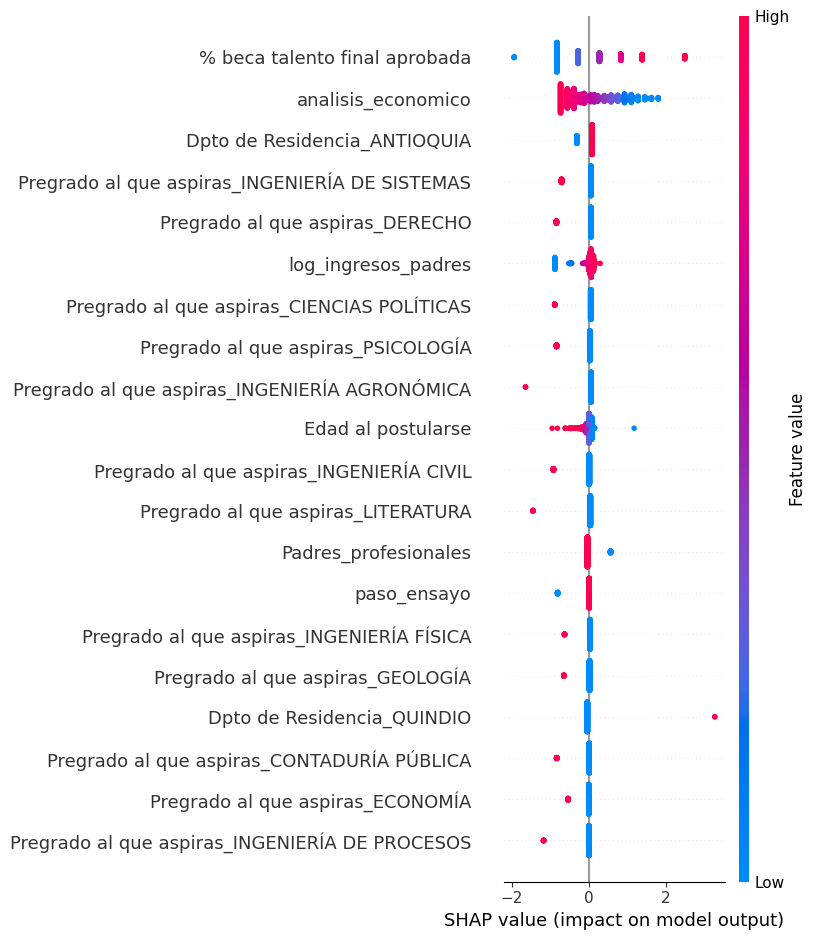

In [ ]:
import shap
shap.initjs()

# Nos aseguramos de que los datos sean numéricos puros
X_train_shap = X_train.astype(float)
X_test_shap  = X_test.astype(float)

# Creamos el masker y el explainer moderno
masker = shap.maskers.Independent(X_train_shap)

explainer = shap.Explainer(best_lr, masker)

# Calculamos valores SHAP sobre el test
shap_values = explainer(X_test_shap)

# Gráfico tipo "dot"
shap.summary_plot(
    shap_values.values,
    X_test_shap,
    feature_names=X_test_shap.columns,
    plot_type="dot"
)


In [ ]:
import joblib

# 1. Elegimos nuestro mejor modelo según df_modelos (ajusta el nombre si es otro)
best_matric_model = grid_lr

# 2. Guardamos también la lista de columnas usadas en X_train (dummies)
matric_package = {
    "model": best_matric_model,
    "columns": X_train.columns.tolist()
}

# 3. Guardamos el paquete en un .joblib
joblib.dump(matric_package, "/content/modelo_clf_matricula.joblib")

print("Modelo de matriculado/no matriculado guardado como modelo_clf_matricula.joblib")


Modelo de matriculado/no matriculado guardado como modelo_clf_matricula.joblib
